# Задание 1: 
**Курс/Имя：** ИУ1-И-41М  Гэ Сюй  

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline

print("Загрузка прошла успешно.！")

Загрузка прошла успешно.！


## Шаг 1: Загрузка и визуализация набора данных (Pairplot)
Загрузка набора данных Iris, построение карт распределения признаков и наблюдение за различиями между различными сортами.

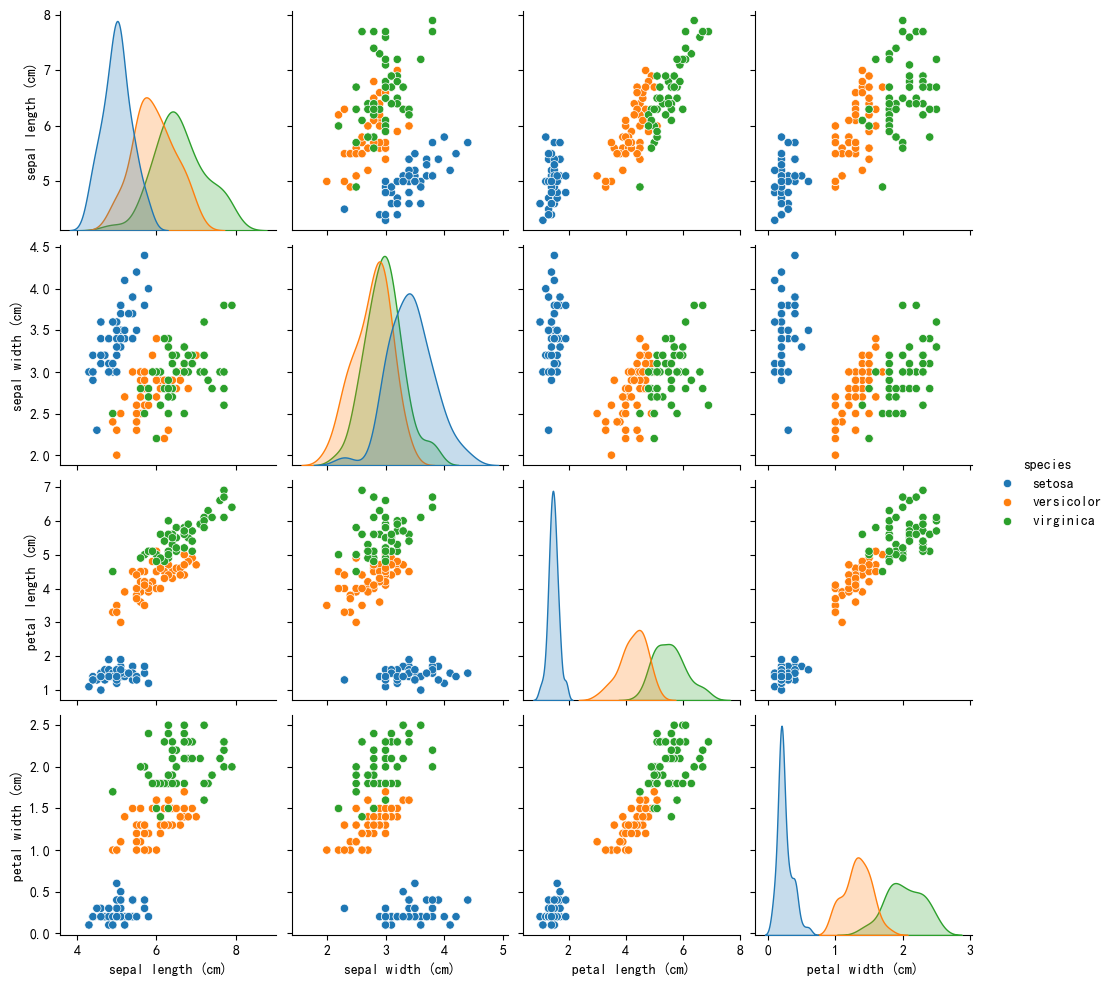

In [7]:
from sklearn.datasets import load_iris

# 1. Загрузка набора данных
raw_data = load_iris()

iris = pd.DataFrame(data=np.c_[raw_data['data'], raw_data['target']],
                     columns=raw_data['feature_names'] + ['target'])

# 2. Название сорта
target_names = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
iris['species'] = iris['target'].map(target_names)

# 3. Удаление избыточных числовых столбцов
iris = iris.drop(columns=['target'])

# 4. 
sns.pairplot(iris, hue='species', diag_kind='kde')
plt.show()

**Выводы по результатам анализа данных：**
1. Анализ диаграммы рассеяния показал, что сорт `Setosa` продемонстрировал явное группирование по всем характерным комбинациям и полностью отделился от двух других сортов.
2. `Petal Length` (Длина лепестка) и  `Petal Width` (ширина лепестка) являются ключевыми показателями для различения сортов.
3. У сортов `Versicolor` и `Virginica` наблюдаются некоторые сходства в признаках чашелистиков, но их можно приблизительно различить по линейным границам в признаках лепестков.

## Шаг 2: Построение модели бинарной классификации на основе логистической регрессии


In [8]:
# 1. Подготовка данных для бинарной классификации
# Удаление сорта "virginica"
df_binary = iris[iris['species'] != 'virginica'].copy()

# 2. Извлечение признаков (X) и меток (y).
X = df_binary.drop('species', axis=1)
y = (df_binary['species'] == 'versicolor').astype(int) # setosa - 0, versicolor - 1

# 3. Разделение обучающей и тестовой выборок (70% обучающая, 30% тестовая).
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 4. Инициализировать и обучить модель логистической регрессии.
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

# 5. 
accuracy = log_model.score(X_test, y_test)
print(f"【Оценка модели】")
print(f"Столбцы признаков, используемые для обучения: {list(X.columns)}")
print(f"Точность бинарной классификации при логистической регрессии: {accuracy * 100:.2f}%")

# 6. Сравнение результатов прогнозирования с фактическими метками.
predictions = log_model.predict(X_test)
print(f"Прогнозируемые значения первых 5 тестовых образцов: {predictions[:5]}")
print(f"Истинные значения первых 5 тестовых образцов: {y_test.values[:5]}")

【Оценка модели】
Столбцы признаков, используемые для обучения: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Точность бинарной классификации при логистической регрессии: 100.00%
Прогнозируемые значения первых 5 тестовых образцов: [1 1 1 0 0]
Истинные значения первых 5 тестовых образцов: [1 1 1 0 0]


## Шаг 3: Демонстрация переобучения в линейной регрессии
Путем добавления шума к синусоидальной функции для генерации данных, а затем аппроксимации данных полиномами разных порядков, демонстрируются различия между **недообучение**, **нормальное обучение** и **переобучение**.

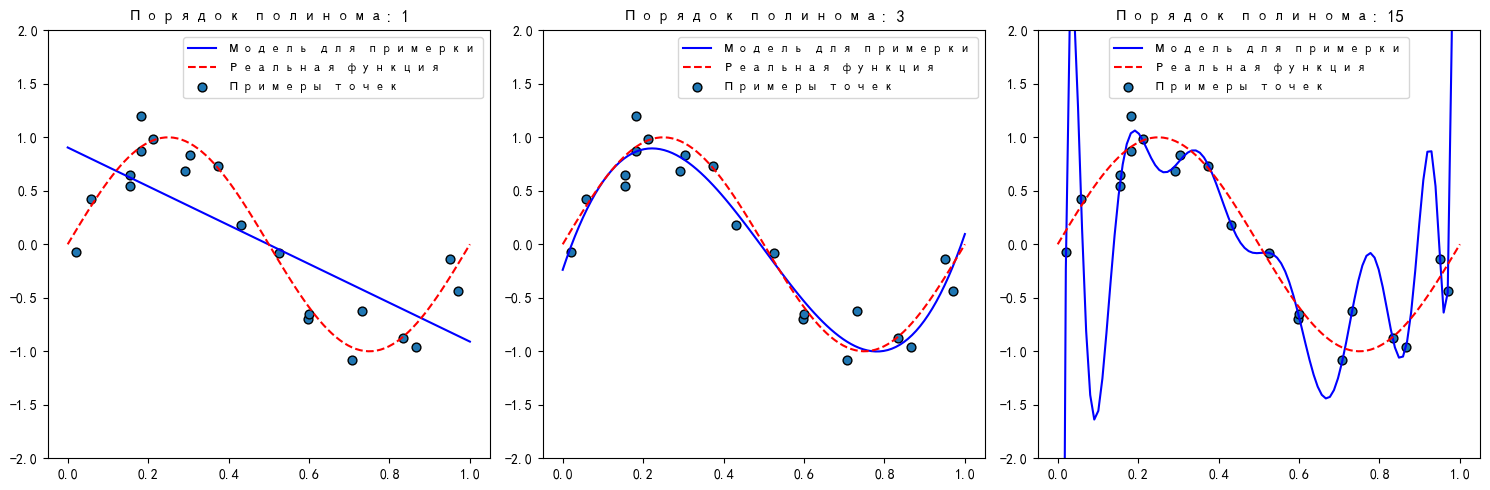

In [11]:
# Сгенерировать зашумленные выборочные данные (на основе синусоидальной кривой).
np.random.seed(42)
X_samples = np.sort(np.random.rand(20))
y_samples = np.sin(2 * np.pi * X_samples) + np.random.randn(20) * 0.2


degrees = [1, 3, 15] # 1=недообучение, 3=*нормальное обучение, 15=переобучение
plt.figure(figsize=(15, 5))

# Результаты
for i, degree in enumerate(degrees):
    ax = plt.subplot(1, 3, i + 1)
    
    # Генерация признаков и линейная регрессия
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_samples[:, np.newaxis], y_samples)
    
    # Построение аппроксимированной кривой
    X_test_plot = np.linspace(0, 1, 100)
    y_pred = model.predict(X_test_plot[:, np.newaxis])
    
    plt.plot(X_test_plot, y_pred, color='blue', label="Модель для примерки")
    plt.plot(X_test_plot, np.sin(2 * np.pi * X_test_plot), "--", color='red', label="Реальная функция")
    plt.scatter(X_samples, y_samples, edgecolor='black', s=40, label="Примеры точек")
    
    plt.ylim(-2, 2)
    plt.title(f"Порядок полинома: {degree}")
    plt.legend(loc="best")

plt.tight_layout()
plt.show()

**Выходы：**
1. **Модель порядка 1**：Кривая представляет собой прямую линию и не может отразить колебания, что является случаем **недообучение**.。
2. **Модель порядка 3**：Она плавно вписывается в основной тренд и демонстрирует **нормальное обучение**.
3. **Модель порядка 15**：Кривая сильно искажена, пытаясь пройти через каждую зашумленную точку. Хотя ошибка на обучающем наборе минимальна, модель полностью теряет способность прогнозировать новые данные, что является типичным случаем **переобучение**.